# Getting Started with ySights

This tutorial introduces the basics of ySights, a Python library for analyzing data from YSocial simulations.

## What You'll Learn

- How to initialize the YDataHandler
- Loading and exploring simulation data
- Working with Agents and Posts
- Basic data queries

## 1. Importing ySights

First, let's import the main components we'll be using:

In [1]:
import os

from ysights import YDataHandler
import matplotlib.pyplot as plt

# Set up matplotlib for nice plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

Obtain the current experiment database handle from the environment variable DB.

In [2]:
db = os.getenv("DB")

## 2. Initializing the Data Handler

The `YDataHandler` is your main interface to the simulation database. It provides methods to query and analyze the data.

In [3]:
# Initialize the data handler
try:
    ydh = YDataHandler(db)
    print("✓ Successfully connected to the database!")
except FileNotFoundError:
    print("✗ Database file not found. Please check the path.")
    print("  For this tutorial, we'll show the expected outputs.")

✓ Successfully connected to the database!


## 3. Exploring the Simulation

Let's get some basic information about the simulation.

In [4]:
# Get simulation time range
time_range = ydh.time_range()
print("Simulation Time Range:")
print(f"  Min Round: {time_range['min_round']}")
print(f"  Max Round: {time_range['max_round']}")


Simulation Time Range:
  Min Round: c3d3833e-7777-4d13-8573-41c04d8f94c6
  Max Round: e9973142-2a55-422d-bd3d-4ae32f1e7451


In [5]:
# Get total number of agents
num_agents = ydh.number_of_agents()
print(f"Total Agents in Simulation: {num_agents}")

Total Agents in Simulation: 101


## 4. Working with Agents

Agents represent the users in the simulation. Let's explore their properties.

In [6]:
# Get all agents
agents = ydh.agents()
print(f"Retrieved {len(agents.get_agents())} agents")

# Look at the first agent
first_agent = agents.get_agents()[0]
print("\nFirst Agent Properties:")
print(f"  ID: {first_agent.id}")
print(f"  Age: {first_agent.age}")
print(f"  Gender: {first_agent.gender}")
print(f"  Education: {first_agent.education}")

Retrieved 101 agents

First Agent Properties:
  ID: 8133bef6-11c7-46d4-997b-6a7d3550bdc9
  Age: 14
  Gender: 4
  Education: bachelor


### Filtering Agents by Feature

You can filter agents based on specific attributes:

In [7]:
# Get agents with age 25
young_agents = ydh.agents_by_feature('age', 25)
print(f"Agents aged 25: {len(young_agents.get_agents())}")

# Get agents by gender
female_agents = ydh.agents_by_feature('gender', 'F')
print(f"Female agents: {len(female_agents.get_agents())}")

Agents aged 25: 2
Female agents: 0


### Age Distribution Visualization

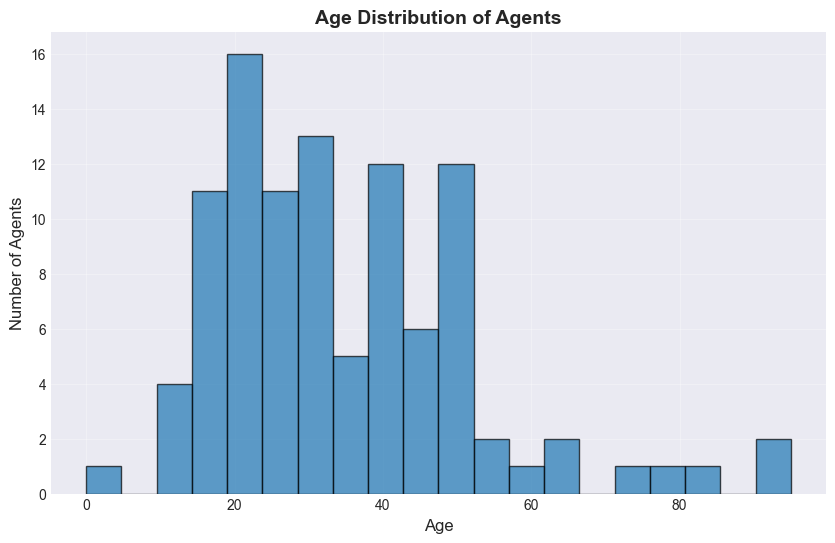

In [8]:
# Collect ages
ages = [agent.age for agent in agents.get_agents()]

# Plot age distribution
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Agents', fontsize=12)
plt.title('Age Distribution of Agents', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Working with Posts

Posts represent the content created by agents in the simulation.

In [9]:
# Get posts by a specific agent
agent_id = 1  # Change this to any valid agent ID
agent_posts = ydh.posts_by_agent(agent_id)

print(f"Agent {agent_id} created {len(agent_posts.get_posts())} posts")

# Examine the first post
if agent_posts.get_posts():
    first_post = agent_posts.get_posts()[0]
    print("\nFirst Post Details:")
    print(f"  Post ID: {first_post.id}")
    print(f"  Author: {first_post.user_id}")
    print(f"  Round: {first_post.round}")
    print(f"  Topic: {first_post.topics}")
    print(f"  Emotion: {first_post.emotions}")

Agent 1 created 0 posts


## 6. Custom Queries

For more complex analysis, you can execute custom SQL queries:

In [10]:
# Example: Get top 5 most active agents
query = """
    SELECT user_id, COUNT(*) as post_count
    FROM post
    GROUP BY user_id
    ORDER BY post_count DESC
    LIMIT 5
"""

results = ydh.custom_query(query)
print("Top 5 Most Active Agents:")
for i, row in enumerate(results, 1):
    print(f"  {i}. Agent {row[0]}: {row[1]} posts")

Top 5 Most Active Agents:
  1. Agent 11d9e964-639e-49a3-a967-dc7dde8341a8: 5 posts
  2. Agent 1d0e1994-4ae5-4ee8-86b3-2ad5245203ad: 4 posts
  3. Agent 8fe760ae-e2e7-4de9-ac3b-73be741daad1: 3 posts
  4. Agent b21fd3e3-34de-4e4b-8db5-bf042fc03cb9: 3 posts
  5. Agent 94ca8699-240e-4d72-b376-d4203b9196ff: 2 posts


## Summary

In this tutorial, you learned:

✓ How to initialize `YDataHandler` with your simulation database
✓ Basic exploration of simulation time range and agent count
✓ Working with `Agents` and filtering by features
✓ Retrieving and examining `Posts`
✓ Executing custom SQL queries for advanced analysis

## Next Steps

Continue exploring ySights using the [official documentation and tutorials](https://ysocialtwin.github.io/ysights/), you will learn to:
- **Network Analysis Tutorial**: Extract and analyze social networks
- **Algorithms Tutorial**: Explore profile similarity, and recommendation metrics
- **Visualization Tutorial**: Create advanced visualizations of simulation data